In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import os
import talib as ta
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

frequency = "1d"
window_pred = 7
# Cargar los datos para esta frecuencia
BTCUSDT = pd.read_csv('BTCUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
AVAXUSDT = pd.read_csv('AVAXUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
XRPUSDT = pd.read_csv('XRPUSDT_1d_01-01-2016_01-01-2025.csv', index_col='timestamp')
data = pd.DataFrame() 

data['BTCUSDT'] = BTCUSDT[['close']]
data['AVAXUSDT'] = AVAXUSDT[['close']]
data['XRPUSDT'] = XRPUSDT[['close']]
data.head()

,BTCUSDT,AVAXUSDT,XRPUSDT
timestamp,,,
2017-08-17,4285.08,NaN,NaN
2017-08-18,4108.37,NaN,NaN
2017-08-19,4139.98,NaN,NaN
2017-08-20,4086.29,NaN,NaN
2017-08-21,4016.00,NaN,NaN


Función para guardar los datos. Hace un archivo por cada frecuencia. Guarda en cada línea el modelo que se ha empleado, el activo, accuracy e in/out-sample.

In [27]:
def save_results_global(model, crypto, acc, sample, frequency='1d'):
    file_name = f'accuracy_results_{frequency}_glob.csv'

    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'What'])

    new_row = pd.DataFrame([[model, crypto, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'What'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)
    df_results.to_csv(file_name, index=False)

Creamos las características que usaremos para hacer el aprendizaje ahora y las retardamos.

In [28]:
def charact_lags(data, ric, lags, window_pred, window=30):
    cols = []
    df = pd.DataFrame(data[ric])
    df['r'] = np.log(df / df.shift()) #retornos
    df['sma'] = df[ric].rolling(window).mean()  #media movil de la ventana
    df['min'] = df[ric].rolling(window).min() #mínimo de la ventana
    df['max'] = df[ric].rolling(window).max() #máximo de la ventana
    df['mom'] = df[ric].pct_change(window) #momentum de la ventana pct_change(12)
    df['vol'] = df['r'].rolling(window).std() #volatilidad de la ventana
    df['rsi'] = ta.RSI(df[ric], timeperiod=window) #rsi de la ventana
    df['atr'] = ta.ATR(df[ric], df[ric], df[ric], timeperiod=window) #atr de la ventana
    df = df.iloc[:-window_pred]
    df['d'] = np.where(df[ric].shift(-window_pred) > df[ric], 1, 0) # columna binaria, 0 si los precios bajarán, 1 si subirán 
    features = [ric, 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
    for f in features:
        for lag in range(1, lags + 1):
            col = f'{f}_lag_{lag}'
            df[col] = df[f].shift(lag)
            cols.append(col)
    return df, cols

lags = 5

dfs = {}
for ric in data:
    df, cols = charact_lags(data, ric, lags, window_pred)
    dfs[ric] = df, cols


In [29]:
#comprueba si los datos están desbalanceados 
df_d = pd.DataFrame()
for ric in data:
    df, cols = dfs[ric]
    df_d[ric] = df['d'].value_counts(normalize=True)
df_d

,BTCUSDT,AVAXUSDT,XRPUSDT
d,,,
1,0.536458,0.28125,0.425595
0,0.463542,0.71875,0.574405


Comentar que he mirado si los datos están desbalanceados 

In [30]:
dfs[ric][0]

,XRPUSDT,r,sma,min,max,mom,vol,rsi,atr,d,...,rsi_lag_1,rsi_lag_2,rsi_lag_3,rsi_lag_4,rsi_lag_5,atr_lag_1,atr_lag_2,atr_lag_3,atr_lag_4,atr_lag_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-08-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-21,2.2380,-0.018286,2.147353,1.3984,2.7245,0.794707,0.078791,61.230947,0.087947,0,...,62.204662,61.629097,63.277124,69.778755,68.774720,0.089555,0.091254,0.091942,0.086250,0.086355
2024-12-22,2.2031,-0.015717,2.171703,1.3984,2.7245,0.496061,0.073957,60.404383,0.086179,0,...,61.230947,62.204662,61.629097,63.277124,69.778755,0.087947,0.089555,0.091254,0.091942,0.086250
2024-12-23,2.2617,0.026251,2.198143,1.3984,2.7245,0.540143,0.073927,61.311540,0.085259,0,...,60.404383,61.230947,62.204662,61.629097,63.277124,0.086179,0.087947,0.089555,0.091254,0.091942


Cambio el formato de los datos para que funcione con el modelo global

In [31]:

cryptos = list(dfs.keys())

df_global = []

for ric, (df, cols) in dfs.items():
    df = df.copy().reset_index()
    df['crypto'] = ric
    df.rename(columns={ric: 'close'}, inplace=True)

    # Renombrar columnas tipo 'BTCUSDT_lag_1' -> 'close_lag_1'
    lag_cols = {f'{ric}_lag_{i}': f'close_lag_{i}' for i in range(1, lags + 1)}
    df.rename(columns=lag_cols, inplace=True)

    df_global.append(df)

# Concatenar todo en un solo DataFrame
df_global = pd.concat(df_global, ignore_index=True)

# Ordenar por fecha
df_global = df_global.sort_values(by='timestamp').reset_index(drop=True)

df_global.dropna(inplace=True)
df_global

,timestamp,close,r,sma,min,max,mom,vol,rsi,atr,...,rsi_lag_2,rsi_lag_3,rsi_lag_4,rsi_lag_5,atr_lag_1,atr_lag_2,atr_lag_3,atr_lag_4,atr_lag_5,crypto
105,2017-09-21,3609.9900,-0.077272,4198.476667,3189.0200,4834.9100,-0.106438,0.065332,43.781986,163.012627,...,46.640426,47.857836,44.074957,44.213417,158.633407,163.757318,165.094811,159.235322,164.210333,BTCUSDT
108,2017-09-22,3595.8700,-0.003919,4181.205333,3189.0200,4834.9100,-0.125945,0.065201,43.651605,158.049539,...,46.542029,46.640426,47.857836,44.074957,163.012627,158.633407,163.757318,165.094811,159.235322,BTCUSDT
113,2017-09-23,3780.0000,0.049938,4163.338333,3189.0200,4834.9100,-0.124191,0.065257,45.827858,158.918888,...,43.781986,46.542029,46.640426,47.857836,158.049539,163.012627,158.633407,163.757318,165.094811,BTCUSDT
115,2017-09-24,3660.0200,-0.032255,4142.649667,3189.0200,4834.9100,-0.144991,0.065453,44.665062,157.620925,...,43.651605,43.781986,46.542029,46.640426,158.918888,158.049539,163.012627,158.633407,163.757318,BTCUSDT
118,2017-09-25,3920.7500,0.068814,4128.760000,3189.0200,4834.9100,-0.096068,0.066767,47.651044,161.057894,...,45.827858,43.651605,43.781986,46.542029,157.620925,158.918888,158.049539,163.012627,158.633407,BTCUSDT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,2024-12-24,98663.5800,0.039087,98381.171000,91965.1600,106133.7400,0.007799,0.025230,57.773555,1730.867671,...,54.791636,57.141430,57.724947,57.443840,1660.135177,1706.870873,1693.117454,1733.795642,1781.734113,BTCUSDT
8060,2024-12-24,41.2500,0.053273,46.232000,36.5700,53.9800,-0.019258,0.065316,51.054260,1.953744,...,46.890348,47.590124,49.646051,48.742458,1.947322,1.926885,1.964018,1.947605,1.979247,AVAXUSDT
8061,2024-12-25,40.2500,-0.024541,46.196667,36.5700,53.9800,-0.025660,0.065387,50.168802,1.921953,...,49.199477,46.890348,47.590124,49.646051,1.953744,1.947322,1.926885,1.964018,1.947605,AVAXUSDT
8062,2024-12-25,99429.6000,0.007734,98595.157333,91965.1600,106133.7400,0.069020,0.023303,58.408279,1698.706082,...,54.456312,54.791636,57.141430,57.724947,1730.867671,1660.135177,1706.870873,1693.117454,1733.795642,BTCUSDT


In [32]:
df_global.columns

Index(['timestamp', 'close', 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi',
       'atr', 'd', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_4',
       'close_lag_5', 'r_lag_1', 'r_lag_2', 'r_lag_3', 'r_lag_4', 'r_lag_5',
       'sma_lag_1', 'sma_lag_2', 'sma_lag_3', 'sma_lag_4', 'sma_lag_5',
       'min_lag_1', 'min_lag_2', 'min_lag_3', 'min_lag_4', 'min_lag_5',
       'max_lag_1', 'max_lag_2', 'max_lag_3', 'max_lag_4', 'max_lag_5',
       'mom_lag_1', 'mom_lag_2', 'mom_lag_3', 'mom_lag_4', 'mom_lag_5',
       'vol_lag_1', 'vol_lag_2', 'vol_lag_3', 'vol_lag_4', 'vol_lag_5',
       'rsi_lag_1', 'rsi_lag_2', 'rsi_lag_3', 'rsi_lag_4', 'rsi_lag_5',
       'atr_lag_1', 'atr_lag_2', 'atr_lag_3', 'atr_lag_4', 'atr_lag_5',
       'crypto'],
      dtype='object')

Hacemos una función que entrene el modelo, lo valide utilizando walk-forward y calcule el accuracy.

In [33]:
def normalize_with_close(X, close_col):
    """
    Normaliza columnas ratio en función del precio de cierre.
    """
    ratio_cols = [col for col in X.columns if any(x in col for x in ['sma','atr','min','max'])]
    for col in ratio_cols:
        X[col] = X[col] / close_col
    return X

# ---------------------------------------------------
def prepare_features(df):
    """
    One-hot encoding de la columna 'crypto'.
    """
    crypto_dummies = pd.get_dummies(df['crypto'], prefix='crypto')
    X = pd.concat([df.drop(columns=['crypto']), crypto_dummies], axis=1)
    return X, crypto_dummies.columns

# ---------------------------------------------------

Versión que prueba varios modelos

In [12]:
def walk_forward_fit_test(model_class, data, freq, search_space, model_params={}, n_trials=5):
    if freq == '1h':
        period = pd.Timedelta(days=7)
    elif freq == '4h':
        period = pd.Timedelta(days=15)
    else:
        period = pd.Timedelta(days=90)
    final_test_period = pd.Timedelta(days=365)

    def normalize_with_close(X, close_col):
        ratio_cols = [col for col in X.columns if any(x in col for x in ['sma', 'atr', 'min', 'max'])]
        for col in ratio_cols:
            X[col] = X[col] / close_col
        return X

    def prepare_features(df):
        df = df.copy()
        crypto_dummies = pd.get_dummies(df['crypto'], prefix='crypto')
        df = pd.concat([df.drop(columns=['crypto']), crypto_dummies], axis=1)
        return df, crypto_dummies.columns

    def objective(trial):
        # Construcción dinámica de parámetros desde el espacio definido
        trial_params = {}
        for param_name, param_info in search_space.items():
            if param_info['type'] == 'int':
                trial_params[param_name] = trial.suggest_int(param_name, *param_info['bounds'])
            elif param_info['type'] == 'float':
                trial_params[param_name] = trial.suggest_float(param_name, *param_info['bounds'], log=param_info.get('log', False))
            elif param_info['type'] == 'categorical':
                trial_params[param_name] = trial.suggest_categorical(param_name, param_info['choices'])
        # Añadir parámetros fijos (p.ej., random_state, class_weight, etc.)
        trial_params.update(model_params)

        # Preparación de datos
        df = data.copy()
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.dropna(inplace=True)

        # Definición de periodos de validación
        max_time = df['timestamp'].max()
        cutoff = max_time - final_test_period
        df_trainval = df[df['timestamp'] < cutoff]

        # Generar fechas de split (últimos 5 períodos)
        min_time = df_trainval['timestamp'].min()
        split_dates = []
        current = min_time + period
        while current < cutoff:
            split_dates.append(current)
            current += period
        split_dates = split_dates[-5:]

        # Listas para métricas
        results_acc = []
        results_f1 = []

        for split_date in split_dates:
            # División train/test para este split
            train = df_trainval[df_trainval['timestamp'] < (split_date - pd.Timedelta(days=window_pred))]
            test  = df_trainval[(df_trainval['timestamp'] >= split_date) \
                                & (df_trainval['timestamp'] < split_date + period)]
            if len(test) == 0:
                continue

            # Columnas a eliminar (incluye timestamp, crypto y todas las _close)
            drop_cols = ['d', 'timestamp', 'crypto', 'close', 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr'] \
                        + [c for c in train.columns if c.startswith('close')]
            X_train = train.drop(columns=drop_cols)
            y_train = train['d']
            X_test  = test.drop(columns=drop_cols)
            y_test  = test['d']

            # Normalización z-score
            mean, std = X_train.mean(), X_train.std()
            std.replace(0, 1, inplace=True)
            X_train = (X_train - mean) / std
            X_test  = (X_test  - mean) / std

            # Entrenamiento con sample_weight solo para GradientBoosting
            model = model_class(**trial_params)
            if model_class.__name__ == 'GradientBoostingClassifier':
                from sklearn.utils.class_weight import compute_sample_weight
                w = compute_sample_weight(class_weight='balanced', y=y_train)
                model.fit(X_train, y_train, sample_weight=w)
            else:
                model.fit(X_train, y_train)

            # Predicción y métricas
            preds = np.where(model.predict(X_test) > 0.5, 1, 0)
            results_acc.append(accuracy_score(y_test, preds))
            results_f1.append(f1_score(y_test, preds, zero_division=0))

        # Métricas promedio de validación
        avg_acc = np.mean(results_acc)
        avg_f1  = np.mean(results_f1)
        print(f'VALIDATION | acc={avg_acc:.4f} | f1={avg_f1:.4f}')
        return avg_f1


    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params
    print("Mejores parámetros encontrados:", best_params)

    # Entrenamiento final con los mejores parámetros
    df = data.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['d'] = (df['close'].shift(-window_pred) > df['close']).astype(int)
    df.dropna(inplace=True)

    max_time = df['timestamp'].max()
    cutoff = max_time - final_test_period

    train = df[df['timestamp'] < (cutoff - pd.Timedelta(days=window_pred))]
    test = df[df['timestamp'] >= cutoff]

    if len(test) == 0:
        return best_params

    drop_cols = ['d', 'close', 'r', 'sma', 'min', 'max', 'mom', 'vol', 
                  'rsi', 'atr'] # close... se eliminan después de normalizar los datos con close_lag_1
    X_train_raw, y_train = train.drop(columns=drop_cols), train['d']
    X_test_raw, y_test = test.drop(columns=drop_cols), test['d']
    cryptos_test = test['crypto'].values

    # Normalizar
    close_train, close_test = train['close_lag_1'], test['close_lag_1']
    X_train_raw = normalize_with_close(X_train_raw.copy(), close_train)
    X_test_raw = normalize_with_close(X_test_raw.copy(), close_test)

    # One-hot encoding
    X_train, _ = prepare_features(X_train_raw)
    X_test, _ = prepare_features(X_test_raw)

    mean, std = X_train.mean(), X_train.std()
    std.replace(0, 1, inplace=True)
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    final_params = best_params.copy()
    if model_class.__name__ == "MLPClassifier" and "hidden_units" in final_params:
        hidden_units = final_params.pop("hidden_units")
        final_params["hidden_layer_sizes"] = (hidden_units,)
    model = model_class(**final_params)
    
    if model_class.__name__ == "GradientBoostingClassifier":
        from sklearn.utils.class_weight import compute_sample_weight
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    pred = np.where(model.predict(X_test) > 0.5, 1, 0)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f'FINAL TEST | acc={acc:.4f} | f1={f1:.4f}')
    print(f'desbalanceo de los datos reales {y_test.value_counts(normalize=True)}')
    print(f'desbalanceo de las predicciones {pd.Series(pred).value_counts(normalize=True)}')
    save_results_global(model_class.__name__, "global", acc, "FINAL TEST", frequency=freq)
    save_results_global(model_class.__name__, "global", f1, "F1 FINAL TEST", frequency=freq)

    # Preparar DataFrame de resultados por criptomoneda
    df_results_test = X_test.copy()
    df_results_test['true'] = y_test.values
    df_results_test['pred'] = pred
    df_results_test['crypto'] = cryptos_test

    # Métricas por criptomoneda
    print("\nFINAL TEST - Accuracy y F1 por criptomoneda:")
    grouped = df_results_test.groupby('crypto')
    for crypto, group in grouped:
        acc_c = accuracy_score(group['true'], group['pred'])
        f1_c = f1_score(group['true'], group['pred'], zero_division=0)  # evita error si solo hay una clase
        print(f"{crypto:<15} | acc = {acc_c:.4f} | f1 = {f1_c:.4f}")
        print(f"    Desbalanceo reales      : {group['true'].value_counts(normalize=True).to_dict()}")
        print(f"    Desbalanceo predicciones: {group['pred'].value_counts(normalize=True).to_dict()}")
        save_results_global(model_class.__name__, crypto, acc_c, "CRYPTO TEST", frequency=freq)
        save_results_global(model_class.__name__, crypto, f1_c, "F1 CRYPTO TEST", frequency=freq)

    return final_params


In [ ]:
# === Definición del espacio de búsqueda para cada modelo ===

search_spaces = {
    "MLPClassifier": {
        "hidden_layer_sizes": {"type": "int",   "bounds": (32, 1024), "step": 32},
        "alpha":              {"type": "float", "bounds": (1e-6, 1e-1), "log": True},
        "learning_rate_init": {"type": "float", "bounds": (1e-5, 1e-1), "log": True},
    },
    "RandomForestClassifier": {
        "n_estimators":      {"type": "int",         "bounds": (100, 1000), "step": 100},
        "max_depth":         {"type": "int",         "bounds": (3,   30)},
        "min_samples_split": {"type": "int",         "bounds": (2,   10)},
        "min_samples_leaf":  {"type": "int",         "bounds": (1,   10)},
        "max_features":      {"type": "categorical", "choices": ["sqrt", "log2", None]},
        "bootstrap":         {"type": "categorical", "choices": [True, False]},
    },
    "GradientBoostingClassifier": {
        "n_estimators":      {"type": "int",   "bounds": (50, 500),  "step": 50},
        "learning_rate":     {"type": "float", "bounds": (1e-3, 0.3), "log": True},
        "max_depth":         {"type": "int",   "bounds": (3,   15)},
        "min_samples_split": {"type": "int",   "bounds": (2,   20)},
        "min_samples_leaf":  {"type": "int",   "bounds": (1,   20)},
    },
}

# === Parámetros fijos para cada modelo ===

model_fixed_params = {
    "MLPClassifier": {
        "max_iter": 1000,
        "early_stopping": True,
        "validation_fraction": 0.15,
        "shuffle": False,
        "random_state": 100,
    },
    "RandomForestClassifier": {
        "class_weight": "balanced",
        "random_state": 100,
        "n_jobs": -1
    },
    "GradientBoostingClassifier": {
        "random_state": 100
    }
}

# === Diccionario de clases de modelos ===

model_classes = {
    "MLPClassifier": MLPClassifier,
    "RandomForestClassifier": RandomForestClassifier,
    "GradientBoostingClassifier": GradientBoostingClassifier
}

# === Entrenamiento en bucle ===

best_params_dict = {}

for model_name, model_cls in model_classes.items():
    print(f"\n\n=== Entrenando modelo: {model_name} ===\n")
    
    best_params = walk_forward_fit_test(
        model_class=model_cls,
        data=df_global,
        freq=frequency,
        search_space=search_spaces[model_name],
        model_params=model_fixed_params.get(model_name, {}),
        n_trials=10  
    )

    best_params_dict[model_name] = best_params

print("\n\n=== Mejores hiperparámetros por modelo ===")
for model_name, params in best_params_dict.items():
    print(f"{model_name}: {params}")


[I 2025-06-10 20:15:47,417] A new study created in memory with name: no-name-74401989-f74a-49e4-ace6-618218f6d9a8




=== Entrenando modelo: MLPClassifier ===



In [17]:
def desbalance_real_global(df_all, window_pred, final_days=365):
    # 1) Crea d y elimina solo sus NaNs
    df = df_all.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.dropna()   # <–– SOLO sobre 'd'

    # 2) Define el corte de test
    max_ts = df['timestamp'].max()
    cutoff = max_ts - pd.Timedelta(days=final_days)
    df_test = df[df['timestamp'] >= cutoff]

    # 3) Agrupa y cuenta proporciones
    desbalance = (
        df_test
        .groupby('crypto')['d']
        .value_counts(normalize=True)   # proporciones
        .unstack(fill_value=0)          # convierte a columnas 0/1
    )
    return desbalance

# Uso:
desb = desbalance_real_global(df_global, window_pred=7)
print(desb)


d                0         1
crypto                      
AVAXUSDT  0.524590  0.475410
BTCUSDT   0.437158  0.562842
XRPUSDT   0.505464  0.494536


balancedporcripto

In [34]:
# Se asume que window_pred y save_results_global() están definidos en el ámbito global.
def walk_forward_fit_test(model_class, data, freq, search_space, model_params={}, n_trials=5):
    """
    Walk-forward con pre-splits y preprocesado al estilo del código 1, pero definido dinámicamente según search_space.
    Imprime métricas de validación y test como en cod 2.
    Devuelve: best_params, desb_graf, df_res.
    """
    # Definir periodo según frecuencia
    if freq == '1h':
        period = pd.Timedelta(days=7)
    elif freq == '4h':
        period = pd.Timedelta(days=15)
    else:
        period = pd.Timedelta(days=90)
    final_test_period = pd.Timedelta(days=365)

    # Preprocesar dataset completo
    df = data.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.dropna()

    # Separar train-val y test final
    max_time = df['timestamp'].max()
    cutoff = max_time - final_test_period
    df_trainval = df[df['timestamp'] < cutoff]

    # Generar últimos 5 splits
    min_time = df_trainval['timestamp'].min()
    split_dates = []
    cur = min_time + period
    while cur < cutoff:
        split_dates.append(cur)
        cur += period
    split_dates = split_dates[-5:]

    # Pre-splits para Optuna
    pre_splits = []
    for sd in split_dates:
        tr = df_trainval[df_trainval['timestamp'] < (sd - pd.Timedelta(days=window_pred))]
        te = df_trainval[(df_trainval['timestamp'] >= sd) & (df_trainval['timestamp'] < sd + period)]
        if te.empty:
            continue
        drop_cols = ['d', 'timestamp', 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
        X_tr = tr.drop(columns=drop_cols)
        X_te = te.drop(columns=drop_cols)
        y_tr, y_te = tr['d'].values, te['d'].values
        # Normalizar con close_lag_1 y eliminar columnas 'close'
        X_tr = normalize_with_close(X_tr.copy(), tr['close_lag_1'])
        X_te = normalize_with_close(X_te.copy(), te['close_lag_1'])
        X_tr = X_tr.loc[:, ~X_tr.columns.str.contains('close')]
        X_te = X_te.loc[:, ~X_te.columns.str.contains('close')]
        # One-hot encoding
        X_tr, _ = prepare_features(X_tr)
        X_te, _ = prepare_features(X_te)
        pre_splits.append((X_tr.values, X_te.values, y_tr, y_te))

    # Función objetivo
    def objective(trial):
        params = {}
        for name, info in search_space.items():
            if info['type'] == 'int':
                params[name] = trial.suggest_int(name, *info['bounds'])
            elif info['type'] == 'float':
                params[name] = trial.suggest_float(name, *info['bounds'], log=info.get('log', False))
            else:
                params[name] = trial.suggest_categorical(name, info['choices'])
        params.update(model_params)

        accs, f1s = [], []
        for X_tr, X_te, y_tr, y_te in pre_splits:
            model = model_class(**params)
            if model_class.__name__ != 'MLPClassifier':
                w = compute_sample_weight(class_weight='balanced', y=y_tr)
                model.fit(X_tr, y_tr, sample_weight=w)
            else:
                model.fit(X_tr, y_tr)
            preds = (model.predict(X_te) > 0.5).astype(int)
            accs.append(accuracy_score(y_te, preds))
            f1s.append(f1_score(y_te, preds, average='macro'))
        avg_acc, avg_f1 = np.mean(accs), np.mean(f1s)
        print(f'VALIDATION | acc={avg_acc:.4f} | f1={avg_f1:.4f}')
        dist_true = pd.Series(y_te).value_counts(normalize=True).to_dict()
        dist_pred = pd.Series(preds).value_counts(normalize=True).to_dict()
        save_results_global(model_class.__name__, 'global', avg_acc,  'ACC VALIDATION', frequency=freq)
        save_results_global(model_class.__name__, 'global', avg_f1,  'F1 VALIDATION', frequency=freq)
        print(f"    Desbalanceo reales (val)      : {dist_true}")
        print(f"    Desbalanceo predicciones (val): {dist_pred}")
        save_results_global(model_class.__name__, 'global', dist_true,  'DESBALANCEO REAL VAL', frequency=freq)
        save_results_global(model_class.__name__, 'global', dist_pred,  'DESBALANCEO PREDICCIÓN VAL', frequency=freq)
        return avg_f1

    # Optimización de hiperparámetros
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)
    best_params = study.best_params
    print('Mejores parámetros encontrados:', best_params)

    # Entrenamiento final y test completo
    df = data.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.dropna()
    max_time = df['timestamp'].max()
    cutoff = max_time - final_test_period
    train = df[df['timestamp'] < (cutoff - pd.Timedelta(days=window_pred))]
    test = df[df['timestamp'] >= cutoff]
    if test.empty:
        return best_params, None, None

    drop_cols = ['d', 'timestamp', 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
    X_train, y_tr = train.drop(columns=drop_cols), train['d']
    X_test, y_te = test.drop(columns=drop_cols), test['d']
    crypto_labels = test['crypto'].values

    # Normalizar con close_lag_1 y eliminar 'close'
    X_train = normalize_with_close(X_train.copy(), train['close_lag_1'])
    X_test = normalize_with_close(X_test.copy(), test['close_lag_1'])
    X_train = X_train.loc[:, ~X_train.columns.str.contains('close')]
    X_test = X_test.loc[:, ~X_test.columns.str.contains('close')]

    # One-hot encoding y Z-score
    X_train, _ = prepare_features(X_train)
    X_test, _ = prepare_features(X_test)

    # Ajuste final    
    w_final = compute_sample_weight(class_weight='balanced', y=y_tr)    
    final_params = best_params.copy()
    if model_class.__name__ == 'MLPClassifier' and 'hidden_units' in final_params:
        hidden = final_params.pop('hidden_units')
        final_params['hidden_layer_sizes'] = (hidden,)
    model = model_class(**final_params)
    if model_class.__name__ != 'MLPClassifier':
        w_final = compute_sample_weight(class_weight='balanced', y=y_tr)
        model.fit(X_train, y_tr, sample_weight=w_final)
    else:
        model.fit(X_train, y_tr)
    
    preds = (model.predict(X_test) > 0.5).astype(int)
    acc, f1 = accuracy_score(y_te, preds), f1_score(y_te, preds, average='macro')
    print(f'FINAL TEST | acc={acc:.4f} | f1={f1:.4f}')
    save_results_global(model_class.__name__, 'global', acc, 'ACC FINAL TEST', frequency=freq)
    save_results_global(model_class.__name__, 'global', f1,  'F1 FINAL TEST', frequency=freq)

    # Preparar df_res
    df_res = pd.DataFrame({'true': y_te, 'pred': preds, 'crypto': crypto_labels})

    # Calcular desbalances y pesos finales
    desb_graf = []
    for cr, grp in df_res.groupby('crypto'):
        acc_c = accuracy_score(grp['true'], grp['pred'])
        f1_c  = f1_score(grp['true'], grp['pred'], average='macro')
        # guardar los datos para pintar los gráficos
        dist_true = grp['true'].value_counts(normalize=True).to_dict()
        dist_pred = grp['pred'].value_counts(normalize=True).to_dict()

        real_0 = dist_true.get(0, 0)
        real_1 = dist_true.get(1, 0)
        pred_0 = dist_pred.get(0, 0)
        pred_1 = dist_pred.get(1, 0)

        desb_graf.append({
            "crypto": cr,
            "acc": acc_c,
            "f1": f1_c,
            "real_0": real_0,
            "real_1": real_1,
            "pred_0": pred_0,
            "pred_1": pred_1
        })
        print(f"{cr:<10} | acc={acc_c:.4f} | f1={f1_c:.4f}")
        print(f"    Desbalanceo reales      : {dist_true}")
        print(f"    Desbalanceo predicciones: {dist_pred}")
        save_results_global(model_class.__name__, cr, acc_c, 'ACC CRYPTO TEST', frequency=freq)
        save_results_global(model_class.__name__, cr, f1_c,  'F1 CRYPTO TEST', frequency=freq)
        save_results_global(model_class.__name__, cr, dist_true,  'DESBALANCEO REAL', frequency=freq)
        save_results_global(model_class.__name__, cr, dist_pred,  'DESBALANCEO PREDICCIÓN', frequency=freq)

    print('\nPesos promedio por clase y cripto (entrenamiento final):')
    df_weights = pd.DataFrame({
        'crypto': train['crypto'],
        'y': y_tr,
        'weight': w_final
    })
    for cr, grp in df_weights.groupby('crypto'):
        avg_weights = grp.groupby('y')['weight'].mean().to_dict()
        print(f"{cr:<10} → {avg_weights}")

    desb_graf = pd.DataFrame(desb_graf)

    return best_params, desb_graf, df_res


In [35]:
# === Definición del espacio de búsqueda para cada modelo ===

search_spaces = {
    "MLPClassifier": {
        "hidden_layer_sizes": {"type": "int",   "bounds": (32, 1024), "step": 32},
        "alpha":              {"type": "float", "bounds": (1e-6, 1e-1), "log": True},
        "learning_rate_init": {"type": "float", "bounds": (1e-5, 1e-1), "log": True},
    },
    "RandomForestClassifier": {
        "n_estimators":      {"type": "int",         "bounds": (100, 1000), "step": 100},
        "max_depth":         {"type": "int",         "bounds": (3,   30)},
        "min_samples_split": {"type": "int",         "bounds": (2,   10)},
        "min_samples_leaf":  {"type": "int",         "bounds": (1,   10)},
        "max_features":      {"type": "categorical", "choices": ["sqrt", "log2", None]},
        "bootstrap":         {"type": "categorical", "choices": [True, False]},
    },
    "GradientBoostingClassifier": {
        "n_estimators":      {"type": "int",   "bounds": (50, 500),  "step": 50},
        "learning_rate":     {"type": "float", "bounds": (1e-3, 0.3), "log": True},
        "max_depth":         {"type": "int",   "bounds": (3,   15)},
        "min_samples_split": {"type": "int",   "bounds": (2,   20)},
        "min_samples_leaf":  {"type": "int",   "bounds": (1,   20)},
    },
}

# === Parámetros fijos para cada modelo ===

model_fixed_params = {
    "MLPClassifier": {
        "max_iter": 1000,
        "early_stopping": True,
        "validation_fraction": 0.15,
        "shuffle": False,
        "random_state": 100,
    },
    "RandomForestClassifier": {
        "class_weight": "balanced",
        "random_state": 100,
        "n_jobs": -1
    },
    "GradientBoostingClassifier": {
        "random_state": 100
    }
}

# === Diccionario de clases de modelos ===

model_classes = {
    "MLPClassifier": MLPClassifier,
    "RandomForestClassifier": RandomForestClassifier,
    "GradientBoostingClassifier": GradientBoostingClassifier
}

# === Entrenamiento en bucle ===

best_params_dict = {}
data_graf_dict = {}
desb_graf_dict = {}

for model_name, model_cls in model_classes.items():
    print(f"\n\n=== Entrenando modelo: {model_name} ===\n")
    
    best_params, desb_graf, data_graf  = walk_forward_fit_test(
        model_class=model_cls,
        data=df_global,
        freq=frequency,
        search_space=search_spaces[model_name],
        model_params=model_fixed_params.get(model_name, {}),
        n_trials=1  
    )

    best_params_dict[model_name] = best_params
    data_graf_dict[model_name] = data_graf
    desb_graf_dict[model_name] = desb_graf

print("\n\n=== Mejores hiperparámetros por modelo ===")
for model_name, params in best_params_dict.items():
    print(f"{model_name}: {params}")




=== Entrenando modelo: MLPClassifier ===



[I 2025-06-11 17:05:57,928] A new study created in memory with name: no-name-c27b9cc9-bd79-49f2-a087-d789a8ef0259
[I 2025-06-11 17:06:22,639] Trial 0 finished with value: 0.5068221407150033 and parameters: {'hidden_layer_sizes': 838, 'alpha': 9.89999971703964e-06, 'learning_rate_init': 0.0007381635327981928}. Best is trial 0 with value: 0.5068221407150033.


VALIDATION | acc=0.5176 | f1=0.5068
    Desbalanceo reales (val)      : {1: 0.6306306306306306, 0: 0.36936936936936937}
    Desbalanceo predicciones (val): {1: 0.6756756756756757, 0: 0.32432432432432434}
Mejores parámetros encontrados: {'hidden_layer_sizes': 838, 'alpha': 9.89999971703964e-06, 'learning_rate_init': 0.0007381635327981928}
FINAL TEST | acc=0.5228 | f1=0.5189
AVAXUSDT   | acc=0.5027 | f1=0.4334
    Desbalanceo reales      : {0: 0.5245901639344263, 1: 0.47540983606557374}
    Desbalanceo predicciones: {0: 0.825136612021858, 1: 0.17486338797814208}
BTCUSDT    | acc=0.5410 | f1=0.3945
    Desbalanceo reales      : {1: 0.5628415300546448, 0: 0.4371584699453552}
    Desbalanceo predicciones: {1: 0.9289617486338798, 0: 0.07103825136612021}
XRPUSDT    | acc=0.5246 | f1=0.4286
    Desbalanceo reales      : {0: 0.505464480874317, 1: 0.49453551912568305}
    Desbalanceo predicciones: {0: 0.9043715846994536, 1: 0.09562841530054644}

Pesos promedio por clase y cripto (entrenamiento f

[I 2025-06-11 17:06:33,046] A new study created in memory with name: no-name-4952a955-6ed8-4093-a629-448fae33e162
[I 2025-06-11 17:10:12,935] Trial 0 finished with value: 0.4761147247460296 and parameters: {'n_estimators': 683, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.4761147247460296.


VALIDATION | acc=0.4802 | f1=0.4761
    Desbalanceo reales (val)      : {1: 0.6306306306306306, 0: 0.36936936936936937}
    Desbalanceo predicciones (val): {0: 0.5135135135135135, 1: 0.4864864864864865}
Mejores parámetros encontrados: {'n_estimators': 683, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': None, 'bootstrap': False}


KeyboardInterrupt: 

In [ ]:
desb_graf_dict

{'MLPClassifier':      crypto       acc        f1    real_0    real_1    pred_0    pred_1
 0  AVAXUSDT  0.497268  0.500000  0.502732  0.497268  0.491803  0.508197
 1   BTCUSDT  0.931694  0.000000  0.931694  0.068306  1.000000  0.000000
 2   XRPUSDT  0.953552  0.976224  0.046448  0.953552  0.000000  1.000000,
 'RandomForestClassifier':      crypto       acc        f1    real_0    real_1    pred_0    pred_1
 0  AVAXUSDT  0.508197  0.592760  0.502732  0.497268  0.289617  0.710383
 1   BTCUSDT  0.931694  0.000000  0.931694  0.068306  1.000000  0.000000
 2   XRPUSDT  0.890710  0.942197  0.046448  0.953552  0.062842  0.937158,
 'SVC':      crypto       acc        f1    real_0    real_1    pred_0    pred_1
 0  AVAXUSDT  0.480874  0.510309  0.502732  0.497268  0.437158  0.562842
 1   BTCUSDT  0.631148  0.117647  0.931694  0.068306  0.650273  0.349727
 2   XRPUSDT  0.426230  0.586614  0.046448  0.953552  0.565574  0.434426,
 'GradientBoostingClassifier':      crypto       acc        f1    real_

GRÁFICOS DE DESBALANCEO

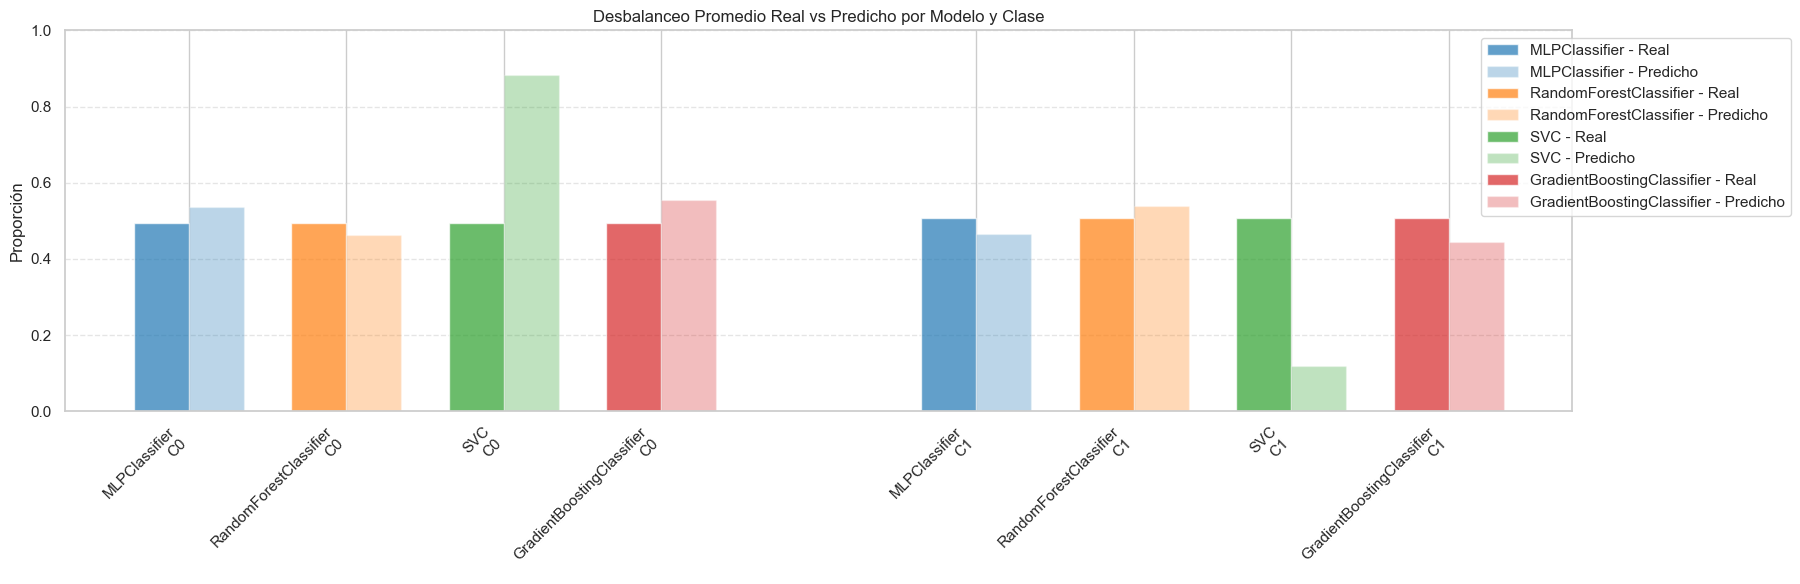

In [ ]:
# Datos para el gráfico
model_names = list(desb_graf_dict.keys())
n_models = len(model_names)
bar_width = 0.35
spacing = 1.0  # espacio entre los grupos de clase 0 y clase 1

# Posiciones en el eje x
x_class_0 = np.arange(n_models)
x_class_1 = x_class_0 + n_models + spacing  # separado por un espacio

fig, ax = plt.subplots(figsize=(18, 6))

colors = plt.cm.tab10.colors  # paleta estándar de 10 colores

for idx, (model_name, data_graf) in enumerate(desb_graf_dict.items()):
    df = pd.DataFrame(data_graf)
    
    real_0 = df['real_0'].mean()
    pred_0 = df['pred_0'].mean()
    real_1 = df['real_1'].mean()
    pred_1 = df['pred_1'].mean()
    
    # barras clase 0
    ax.bar(x_class_0[idx], real_0, width=bar_width, label=f'{model_name} - Real', color=colors[idx], alpha=0.7)
    ax.bar(x_class_0[idx] + bar_width, pred_0, width=bar_width, label=f'{model_name} - Predicho', color=colors[idx], alpha=0.3)
    
    # barras clase 1
    ax.bar(x_class_1[idx], real_1, width=bar_width, color=colors[idx], alpha=0.7)
    ax.bar(x_class_1[idx] + bar_width, pred_1, width=bar_width, color=colors[idx], alpha=0.3)

# Etiquetas y ejes
ax.set_xticks(
    list(x_class_0 + bar_width / 2) + list(x_class_1 + bar_width / 2)
)
ax.set_xticklabels(
    [f'{name}\nC0' for name in model_names] + [f'{name}\nC1' for name in model_names],
    rotation=45, ha='right'
)
ax.set_ylabel('Proporción')
ax.set_title('Desbalanceo Promedio Real vs Predicho por Modelo y Clase')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


      true  pred    crypto
6984     0     1  AVAXUSDT
6985     1     1   XRPUSDT
6986     0     0   BTCUSDT
6987     1     1   XRPUSDT
6988     0     0   BTCUSDT
...    ...   ...       ...
8077     0     0   BTCUSDT
8078     0     1  AVAXUSDT
8079     1     0  AVAXUSDT
8080     0     0   BTCUSDT
8081     0     1   XRPUSDT

[1098 rows x 3 columns]
      true  pred    crypto
6984     0     0  AVAXUSDT
6985     1     1   XRPUSDT
6986     0     0   BTCUSDT
6987     1     1   XRPUSDT
6988     0     0   BTCUSDT
...    ...   ...       ...
8077     0     0   BTCUSDT
8078     0     1  AVAXUSDT
8079     1     1  AVAXUSDT
8080     0     0   BTCUSDT
8081     0     1   XRPUSDT

[1098 rows x 3 columns]
      true  pred    crypto
6984     0     0  AVAXUSDT
6985     1     1   XRPUSDT
6986     0     0   BTCUSDT
6987     1     1   XRPUSDT
6988     0     0   BTCUSDT
...    ...   ...       ...
8077     0     0   BTCUSDT
8078     0     0  AVAXUSDT
8079     1     0  AVAXUSDT
8080     0     0   BTCUSDT
8081 

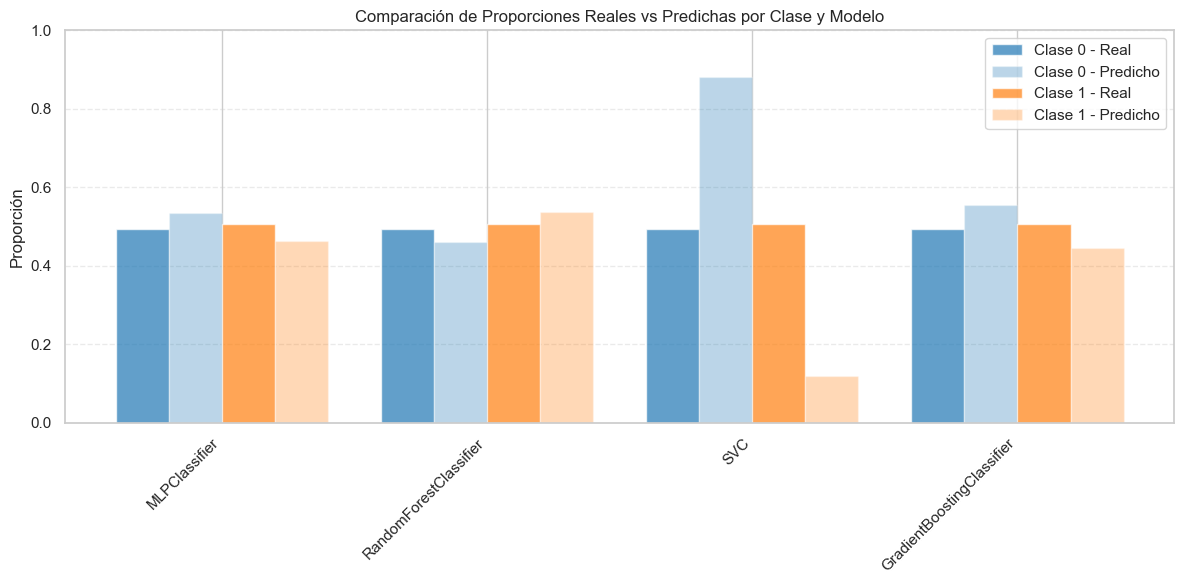

In [ ]:
model_names = []
real_0, real_1, pred_0, pred_1 = [], [], [], []

for model, res in data_graf_dict.items():
    y_test = pd.Series(res["true"])
    y_pred = pd.Series(res["pred"])
    
    real_dist = y_test.value_counts(normalize=True).to_dict()
    pred_dist = y_pred.value_counts(normalize=True).to_dict()

    model_names.append(model)
    real_0.append(real_dist.get(0, 0))
    real_1.append(real_dist.get(1, 0))
    pred_0.append(pred_dist.get(0, 0))
    pred_1.append(pred_dist.get(1, 0))

# Posiciones para las barras
x = np.arange(len(model_names))
bar_width = 0.2

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - 1.5*bar_width, real_0, width=bar_width, label='Clase 0 - Real', color='tab:blue', alpha=0.7)
ax.bar(x - 0.5*bar_width, pred_0, width=bar_width, label='Clase 0 - Predicho', color='tab:blue', alpha=0.3)

ax.bar(x + 0.5*bar_width, real_1, width=bar_width, label='Clase 1 - Real', color='tab:orange', alpha=0.7)
ax.bar(x + 1.5*bar_width, pred_1, width=bar_width, label='Clase 1 - Predicho', color='tab:orange', alpha=0.3)

# Etiquetas y estilo
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Proporción')
ax.set_ylim(0, 1)
ax.set_title('Comparación de Proporciones Reales vs Predichas por Clase y Modelo')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

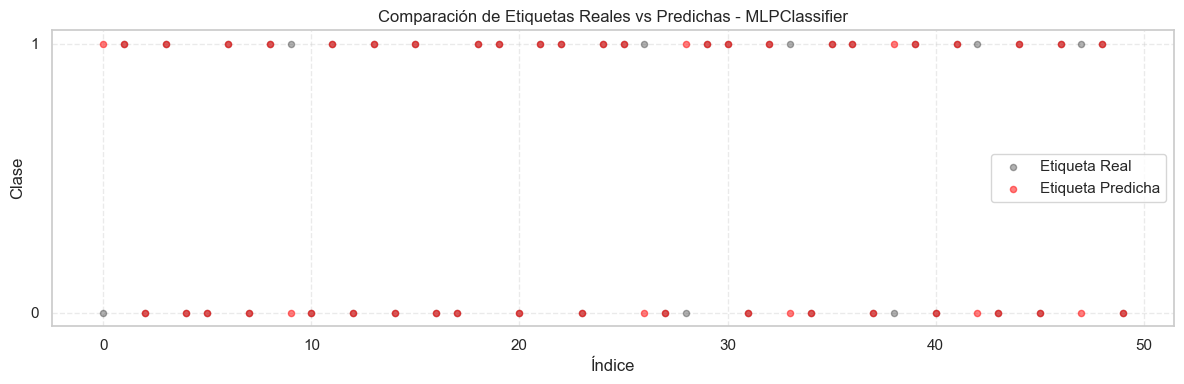

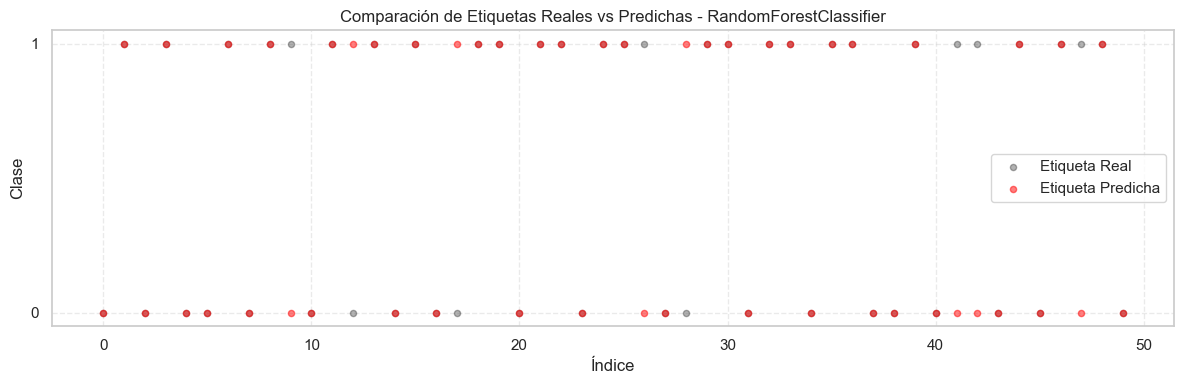

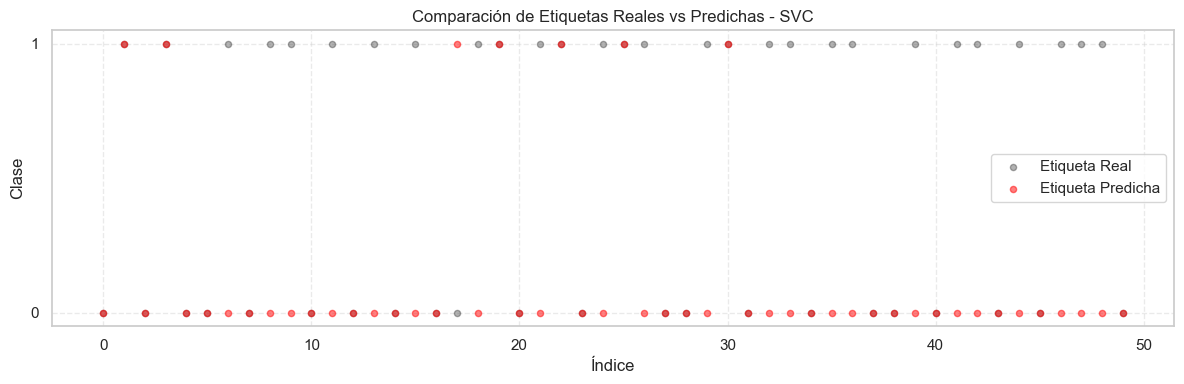

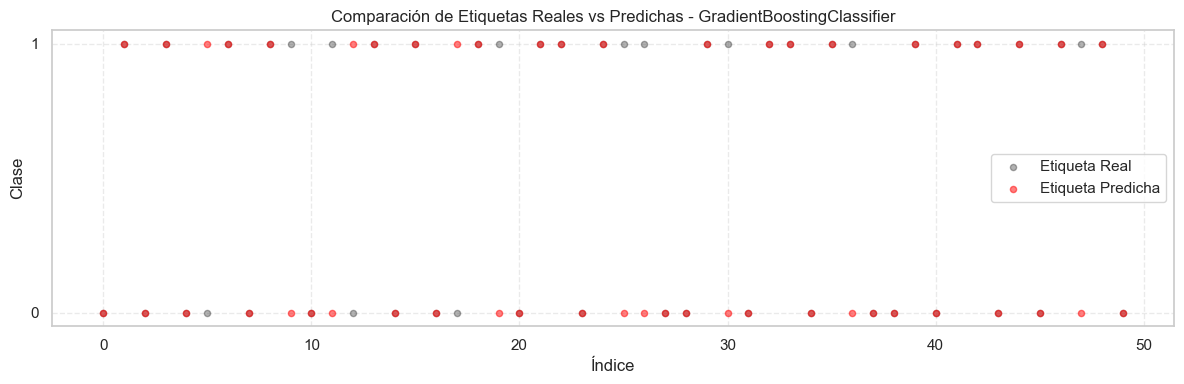

In [ ]:
for model_name, res in data_graf_dict.items():
    res = res[:50]
    y_test = pd.Series(res["true"]).reset_index(drop=True)
    y_pred = pd.Series(res["pred"]).reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.scatter(y_test.index, y_test, label='Etiqueta Real', color='black', alpha=0.3, s=20)
    ax.scatter(y_pred.index, y_pred, label='Etiqueta Predicha', color='red', alpha=0.5, s=20)

    ax.set_title(f'Comparación de Etiquetas Reales vs Predichas - {model_name}')
    ax.set_xlabel('Índice')
    ax.set_ylabel('Clase')
    ax.set_yticks([0, 1])
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

C:\Users\raque\AppData\Local\Temp\ipykernel_39352\548524735.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(models))  # tab10 da 10 colores distintos


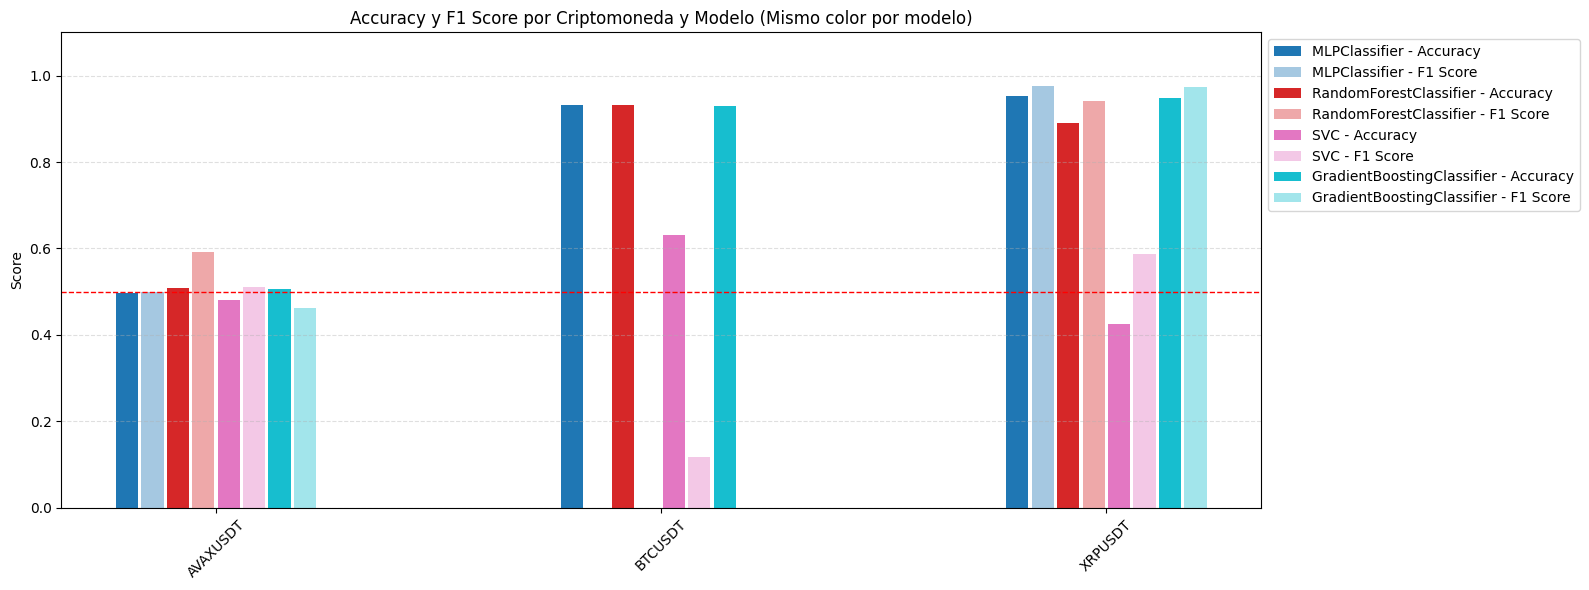

In [ ]:
import matplotlib.cm as cm
df_all = []
for model_name, results in desb_graf_dict.items():
    df_model = pd.DataFrame({
        "crypto": results["crypto"],
        "acc": results["acc"],
        "f1": results["f1"],
        "model": model_name
    })
    df_all.append(df_model)

df = pd.concat(df_all, ignore_index=True)

# Preparar gráfico
cryptos = df["crypto"].unique()
models = df["model"].unique()
metrics = ["acc", "f1"]

fig, ax = plt.subplots(figsize=(16, 6))
bar_width = 0.05
x = np.arange(len(cryptos))

# Paleta de colores base por modelo
colors = cm.get_cmap('tab10', len(models))  # tab10 da 10 colores distintos

# Calcular desplazamientos
total_bars = len(models) * len(metrics)
offsets = np.linspace(-bar_width * total_bars / 2, bar_width * total_bars / 2, total_bars)

for i, model in enumerate(models):
    color_base = colors(i)
    for j, metric in enumerate(metrics):
        values = df[df["model"] == model].set_index("crypto").loc[cryptos][metric]
        alpha = 1.0 if metric == "acc" else 0.4  # Misma base de color, más claro para F1
        label = f"{model} - {'Accuracy' if metric == 'acc' else 'F1 Score'}"
        position = x + offsets[i * len(metrics) + j]
        ax.bar(position, values, width=bar_width, label=label, color=color_base, alpha=alpha)

# Ejes
ax.set_xticks(x)
ax.set_xticklabels(cryptos, rotation=45)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Accuracy y F1 Score por Criptomoneda y Modelo (Mismo color por modelo)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Límite 0.5')
plt.tight_layout()
plt.show()
